In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
fund = pd.read_csv("data/raw/01_fund_master.csv")
nav = pd.read_csv("data/raw/02_nav_history.csv")
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("data/raw/05_category_inflows.csv")

In [12]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

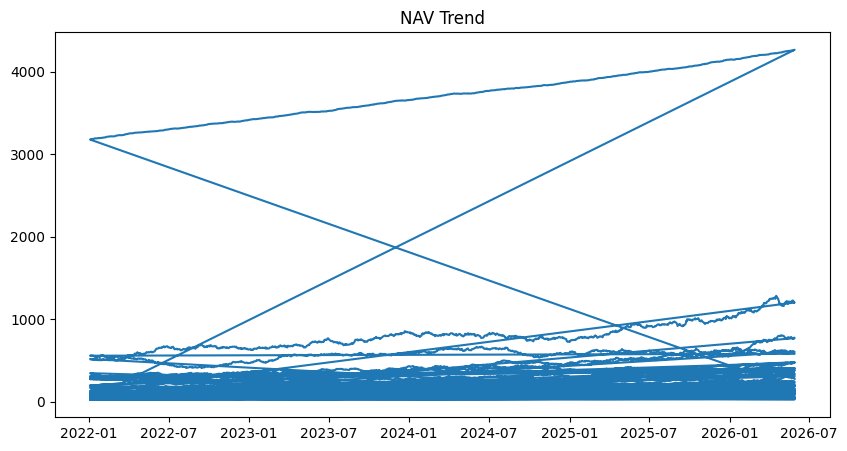

In [6]:
plt.figure(figsize=(10,5))
plt.plot(nav["date"], nav["nav"])
plt.title("NAV Trend")
plt.show()

In [7]:
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


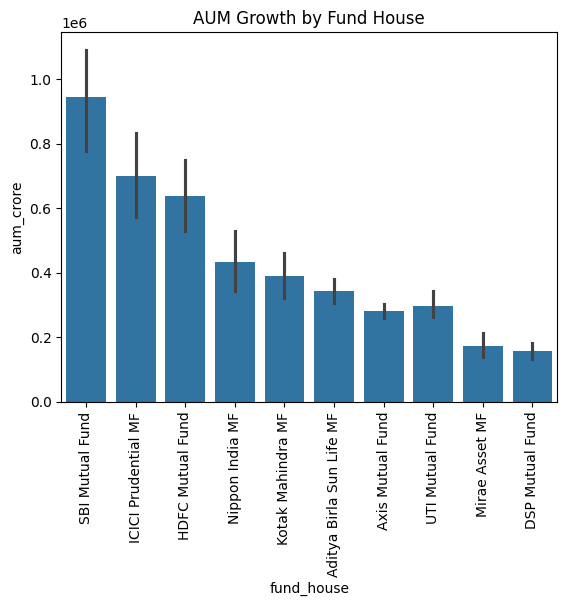

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

print(aum.columns)

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=90)
plt.title("AUM Growth by Fund House")
plt.show()

In [26]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [27]:
x ="fund_house"
y ="aum"

In [28]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


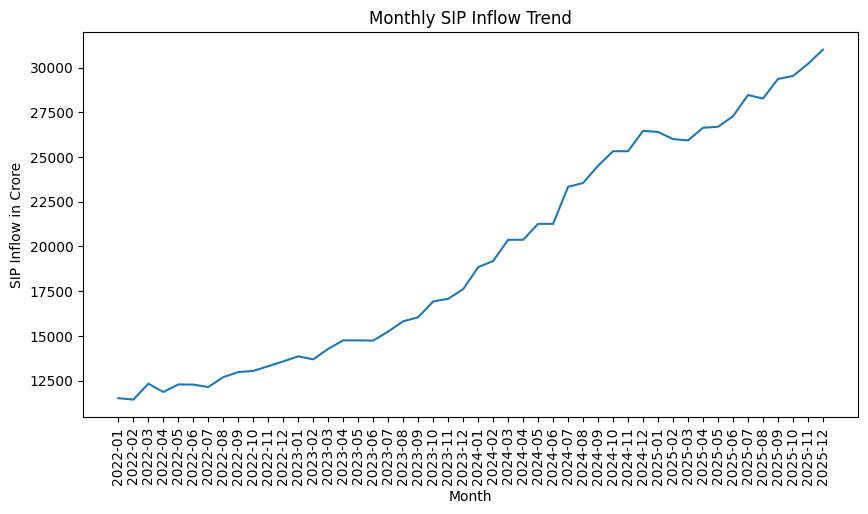

In [35]:
plt.figure(figsize=(10,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.xticks(rotation=90)
plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow in Crore")

plt.show()

In [34]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')


In [36]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [38]:
print(category.columns.tolist())

['month', 'category', 'net_inflow_crore']


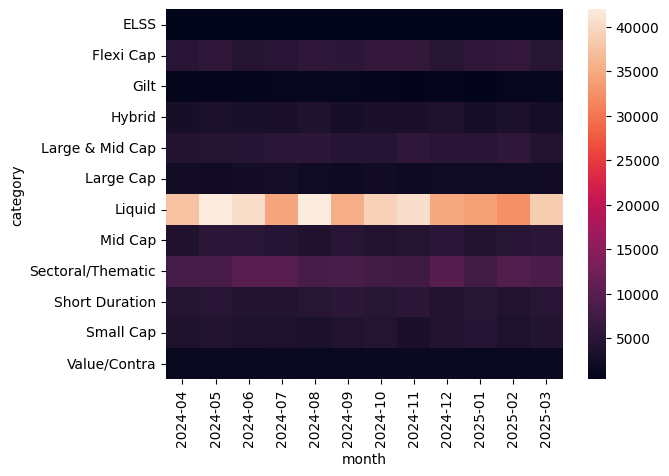

In [44]:
pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

sns.heatmap(pivot)
plt.show()

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

investor = pd.read_csv("data/raw/08_investor_transactions.csv")

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [47]:
print(investor.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


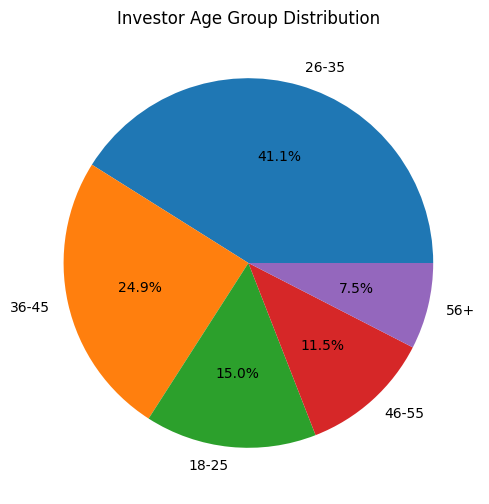

In [48]:
investor["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

In [49]:
print(investor.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


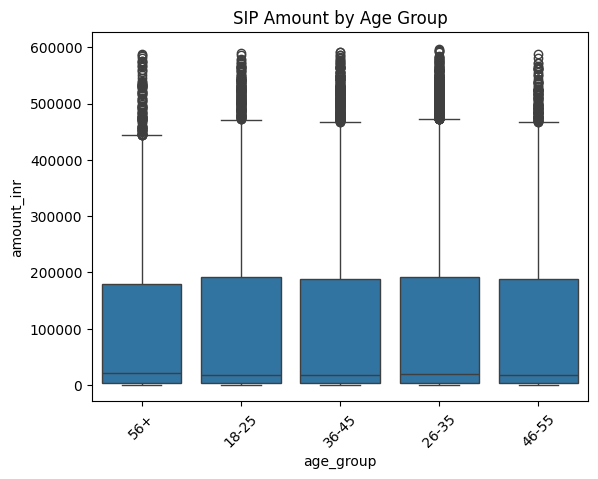

In [50]:
sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.xticks(rotation=45)
plt.title("SIP Amount by Age Group")
plt.show()

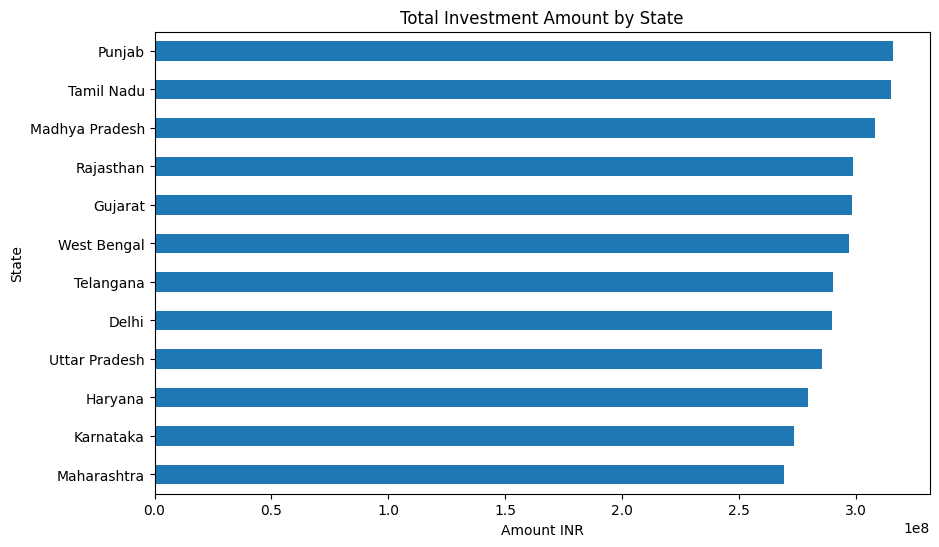

In [51]:
state_data = investor.groupby("state")["amount_inr"].sum().sort_values()

state_data.plot(kind="barh", figsize=(10,6))

plt.title("Total Investment Amount by State")
plt.xlabel("Amount INR")
plt.ylabel("State")
plt.show()

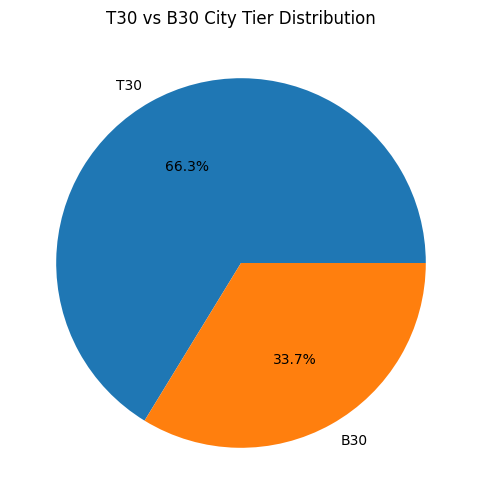

In [52]:
investor["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("T30 vs B30 City Tier Distribution")
plt.ylabel("")
plt.show()

In [53]:
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [54]:
print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [58]:
print(folio.columns.tolist())


['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


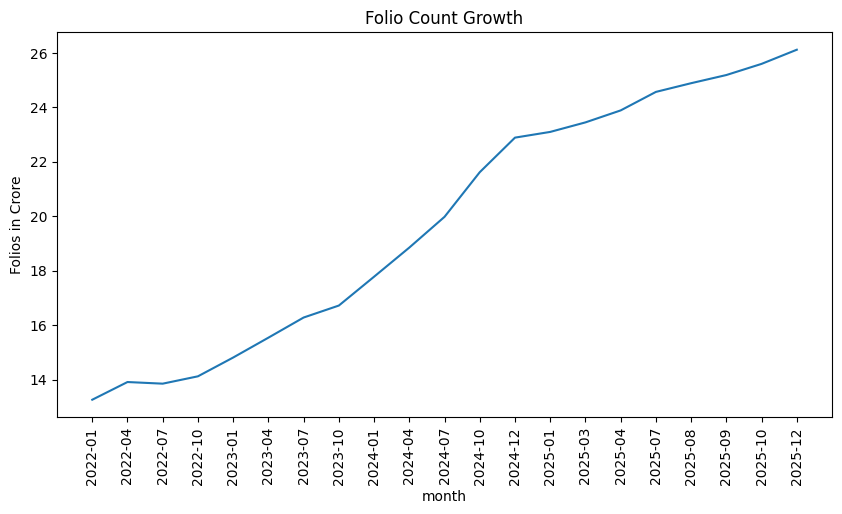

In [61]:
plt.figure(figsize=(10,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.xticks(rotation=90)
plt.title("Folio Count Growth")
plt.xlabel("month")
plt.ylabel("Folios in Crore")
plt.show()

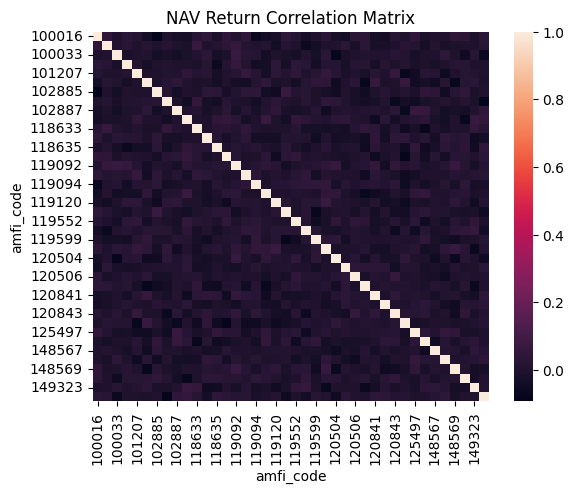

In [62]:
nav = pd.read_csv("data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav_pivot = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = nav_pivot.pct_change()

corr = returns.corr()

sns.heatmap(corr)

plt.title("NAV Return Correlation Matrix")
plt.show()

In [63]:
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [64]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


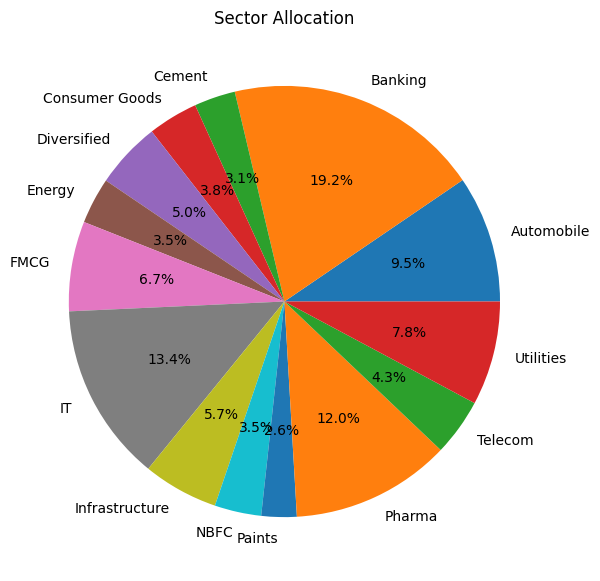

In [65]:
sector = portfolio.groupby("sector")["weight_pct"].sum()

sector.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Sector Allocation")
plt.ylabel("")
plt.show()